# Analog Holidays

Thin orchestration notebook for running `AnalogSpecialDays` from the hourly wide holiday audit CSV.

The loading, normalization, forecasting, and plotting logic lives in `analog/analog_holidays.py`. This notebook only defines parameters and calls the plotting helpers.

The CSV export only preserves holiday flags, so this workflow targets holiday analogs rather than manual `special_day` or outlier labels.

In [12]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import analog_holidays.analog.analog_special_days as analog_special_days_module
import analog_holidays.analog.analog_holidays as analog_holidays_module

analog_special_days_module = importlib.reload(analog_special_days_module)
analog_holidays_module = importlib.reload(analog_holidays_module)

from analog_holidays.analog.analog_holidays import (
    build_analog_ranking_table,
    build_run_summary,
    plot_analog_pair_sequences,
    plot_batch_inference_grid,
    plot_batch_pair_sequences_grid,
    plot_forecast_diagnostics,
    plot_ranked_analog_profiles,
    prepare_audit_working_copy,
    run_analog_holidays,
    run_analog_holidays_batch,
    tune_analog_holidays_optuna,
)

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)

## Parameters

Adjust the series, target date, and analog hyperparameters for the holiday-only CSV source.

- SOURCE_PATH: path to the holiday CSV file consumed by the notebook.
- UNIQUE_ID: target series used to build analogs and generate the forecast.
- TARGET_DATE: target date for which the hourly profile should be estimated.
- SPECIAL_LABELS: labels that define which days are treated as special candidates when selecting analogs.
- SEASON_LENGTH: hourly profile length to model, in hours.
- K: number of special neighbors kept after ranking X against Y by similarity; None uses every filtered candidate.
- TYPEDIST: metric used to rank holiday candidates against Y; supports pearson, euclidian, and dtw.
- TYPEREG: regressor type used in the analog reconstruction step.
- N_COMPONENTS: number of components for dimensionality-reduction methods such as PCR or PLS.
- LEVELS: prediction interval levels to compute for the forecast.
- MIN_SPECIAL_POINTS: minimum number of hours flagged as special inside a candidate block.
- MIN_EVENT_GAP: minimum separation between consecutive special events to avoid overly overlapping candidates.
- MAX_EVENTS: maximum number of special events used as the analog bank; None uses all available events.
- MAX_PLOTTED_ANALOGS: maximum number of analogs shown in the comparative plots.

In [13]:
import shutil
from datetime import datetime

# Original CSV — never modified by this notebook.
_ORIGINAL_SOURCE = PROJECT_ROOT / 'analog_holidays' / 'holidays' / 'holiday_demand_mx.csv'

# Create a fresh timestamped working copy on every notebook launch.
_timestamp = datetime.now().strftime('%Y_%m_%d_%H_%M')
SOURCE_PATH = _ORIGINAL_SOURCE.with_name(f'holiday_demand_mx_{_timestamp}.csv')
shutil.copy2(_ORIGINAL_SOURCE, SOURCE_PATH)
print(f'Working copy: {SOURCE_PATH.name}')

UNIQUE_ID = 'SEN_demand_CEL'
UNIQUE_ID = 'SEN_demand_PEN'
UNIQUE_ID = 'SEN_demand_SIN'

Working copy: holiday_demand_mx_2026_05_23_22_09.csv


In [14]:
SPECIAL_LABELS = ('holiday',)
SEASON_LENGTH = 24
K = 1000
TYPEDIST = 'pearson'
TYPEREG = 'PCR'
N_COMPONENTS = 3
LEVELS = [80, 95]
MIN_SPECIAL_POINTS = 24
MIN_EVENT_GAP = 24
MAX_EVENTS = None
MAX_PLOTTED_ANALOGS = 10

DATE_END = '2024-01-01'  # only dates strictly earlier than this cutoff are included in the study
OPTUNA_N_TRIALS = 25
OPTUNA_TIMEOUT_SEC = 900
OPTUNA_MAX_EVAL_DATES = 12
OPTUNA_RANDOM_SEED = 42

In [15]:
# TARGET_DATES_2025 = [
#     ('2024-01-01', "New Year's Day"),
#     ('2024-02-05', 'Constitution Day'),
#     ('2024-03-18', "Benito Juarez's Birthday"),
#     ('2024-03-28', 'Maundy Thursday'),
#     ('2024-03-29', 'Good Friday'),
#     ('2024-03-30', 'Holy Saturday'),
#     ('2024-05-01', 'Labor Day'),
#     ('2024-09-15', 'Independence Eve'),
#     ('2024-10-01', 'Presidential Inauguration'),
#     ('2024-11-02', 'Day of the Dead'),
#     ('2024-11-18', 'Mexican Revolution Day'),
#     ('2024-12-24', 'Christmas Eve'),
#     ('2024-12-25', 'Christmas Day'),
#     ('2024-12-31', "New Year's Eve"),
      # ===== 2025 =====
TARGET_DATES_2025 = [
    ('2025-01-01', "New Year's Day"),
    ('2025-02-03', 'Constitution Day'),
    ('2025-03-17', "Benito Juarez's Birthday"),
    ('2025-04-17', 'Maundy Thursday'),
    ('2025-04-18', 'Good Friday'),
    ('2025-04-19', 'Holy Saturday'),
    ('2025-05-01', 'Labor Day'),
    ('2025-09-16', 'Independence Day'),
    ('2025-11-17', 'Mexican Revolution Day'),
    ('2025-12-24', 'Christmas Eve'),
    ('2025-12-25', 'Christmas Day'),
    ('2025-12-31', "New Year's Eve"),
    # ===== 2026 =====
    ('2026-01-01', "New Year's Day"),    
    ('2026-02-02', 'Constitution Day'),
    ('2026-03-16', "Benito Juarez's Birthday"),
    ('2026-04-02', 'Maundy Thursday'),
    ('2026-04-03', 'Good Friday'),
    ('2026-04-04', 'Holy Saturday'),
    ('2026-05-01', 'Labor Day'),
    # ('2026-09-15', 'Independence Eve'),
    # ('2026-09-16', 'Independence Day'),
    # ('2026-11-16', 'Mexican Revolution Day'),
    # ('2026-12-24', 'Christmas Eve'),
    # ('2026-12-25', 'Christmas Day'),
    # ('2026-12-31', "New Year's Eve"),
]

TARGET_DATE = TARGET_DATES_2025[-1][0]

In [16]:
optuna_result = tune_analog_holidays_optuna(
    unique_id=UNIQUE_ID,
    source_path=SOURCE_PATH,
    train_end=DATE_END,
    season_length=SEASON_LENGTH,
    initial_k=K,
    initial_typedist=TYPEDIST,
    initial_typereg=TYPEREG,
    initial_n_components=N_COMPONENTS,
    n_trials=OPTUNA_N_TRIALS,
    timeout_sec=OPTUNA_TIMEOUT_SEC,
    max_eval_dates=OPTUNA_MAX_EVAL_DATES,
    random_seed=OPTUNA_RANDOM_SEED,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
 )

K = int(optuna_result.best_config['k'])
TYPEDIST = optuna_result.best_config['typedist']
TYPEREG = optuna_result.best_config['typereg']
N_COMPONENTS = int(optuna_result.best_config['n_components'])

print('Hyperparameters updated for the next notebook run.')
display(optuna_result.summary_df)
optuna_result.fold_metrics_df

Hyperparameters updated for the next notebook run.


,param,value
0,cutoff_train,2024-01-01
1,eval_dates,12
2,best_mean_mae,882.989154
3,best_mean_mape_pct,3.009
4,best_fail_rate,0.0
5,K,10
6,TYPEDIST,euclidian
7,TYPEREG,PCR
8,N_COMPONENTS,8
9,DTW_WINDOW,None


,target_date,mae,mape_pct,selected_analogs,fail,train_days,train_special_days
0,2023-04-06,204.942735,0.588928,10,False,823,34
1,2023-04-07,912.975133,2.987304,10,False,824,35
2,2023-04-08,1373.349833,4.345701,10,False,825,36
3,2023-04-09,449.923478,1.529842,10,False,826,37
4,2023-05-01,950.873931,2.903719,10,False,848,38
5,2023-09-16,626.954037,1.678623,10,False,986,39
6,2023-11-02,939.474475,2.933297,10,False,1033,40
7,2023-11-20,510.554078,1.698601,10,False,1051,41
8,2023-12-12,731.134480,2.279921,10,False,1073,42
9,2023-12-24,1461.603725,5.506231,10,False,1085,43


In [17]:
batch_result_2025 = run_analog_holidays_batch(
    target_dates=TARGET_DATES_2025,
    unique_id=UNIQUE_ID,
    source_path=SOURCE_PATH,
    season_length=SEASON_LENGTH,
    k=K,
    typedist=TYPEDIST,
    typereg=TYPEREG,
    n_components=N_COMPONENTS,
    levels=LEVELS,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
    expected_target_label=None,
 )

display(batch_result_2025.results_df)
batch_result_2025.metric_summary_df

,target_date,holiday_label,target_exists,target_has_complete_profile,selected_analogs,fail,mae_24h,mape_24h_pct,t_sel_sec,t_reg_sec,k,typedist,typereg,n_components,error
0,2025-01-01,New Year's Day,True,True,10,False,309.314577,1.285996,0.003499,0.003989,10,euclidian,PCR,8,None
1,2025-02-03,Constitution Day,True,True,10,False,232.265289,0.810763,0.003989,0.001994,10,euclidian,PCR,8,None
2,2025-03-17,Benito Juarez's Birthday,True,True,10,False,1576.647631,5.330975,0.001994,0.001994,10,euclidian,PCR,8,None
3,2025-04-17,Maundy Thursday,True,True,10,False,394.145217,1.078884,0.001994,0.002993,10,euclidian,PCR,8,None
4,2025-04-18,Good Friday,True,True,10,False,1469.689289,4.414291,0.001961,0.002993,10,euclidian,PCR,8,None
5,2025-04-19,Holy Saturday,True,True,10,False,808.924398,2.486932,0.001995,0.002993,10,euclidian,PCR,8,None
6,2025-05-01,Labor Day,True,True,10,False,314.540911,0.871832,0.001994,0.002992,10,euclidian,PCR,8,None
7,2025-09-16,Independence Day,True,True,10,False,1371.837564,3.693016,0.002993,0.001997,10,euclidian,PCR,8,None
8,2025-11-17,Mexican Revolution Day,True,True,10,False,974.171169,2.988916,0.001995,0.001995,10,euclidian,PCR,8,None
9,2025-12-24,Christmas Eve,True,True,10,False,770.179346,2.591196,0.002992,0.002993,10,euclidian,PCR,8,None


,mae_24h,mape_24h_pct
count,19.000000,19.000000
mean,1086.174330,3.413363
std,733.343924,2.232963
min,232.265289,0.810763
25%,496.828565,1.394990
50%,824.137971,2.988916
75%,1523.168460,4.872633
max,2700.124122,8.120534


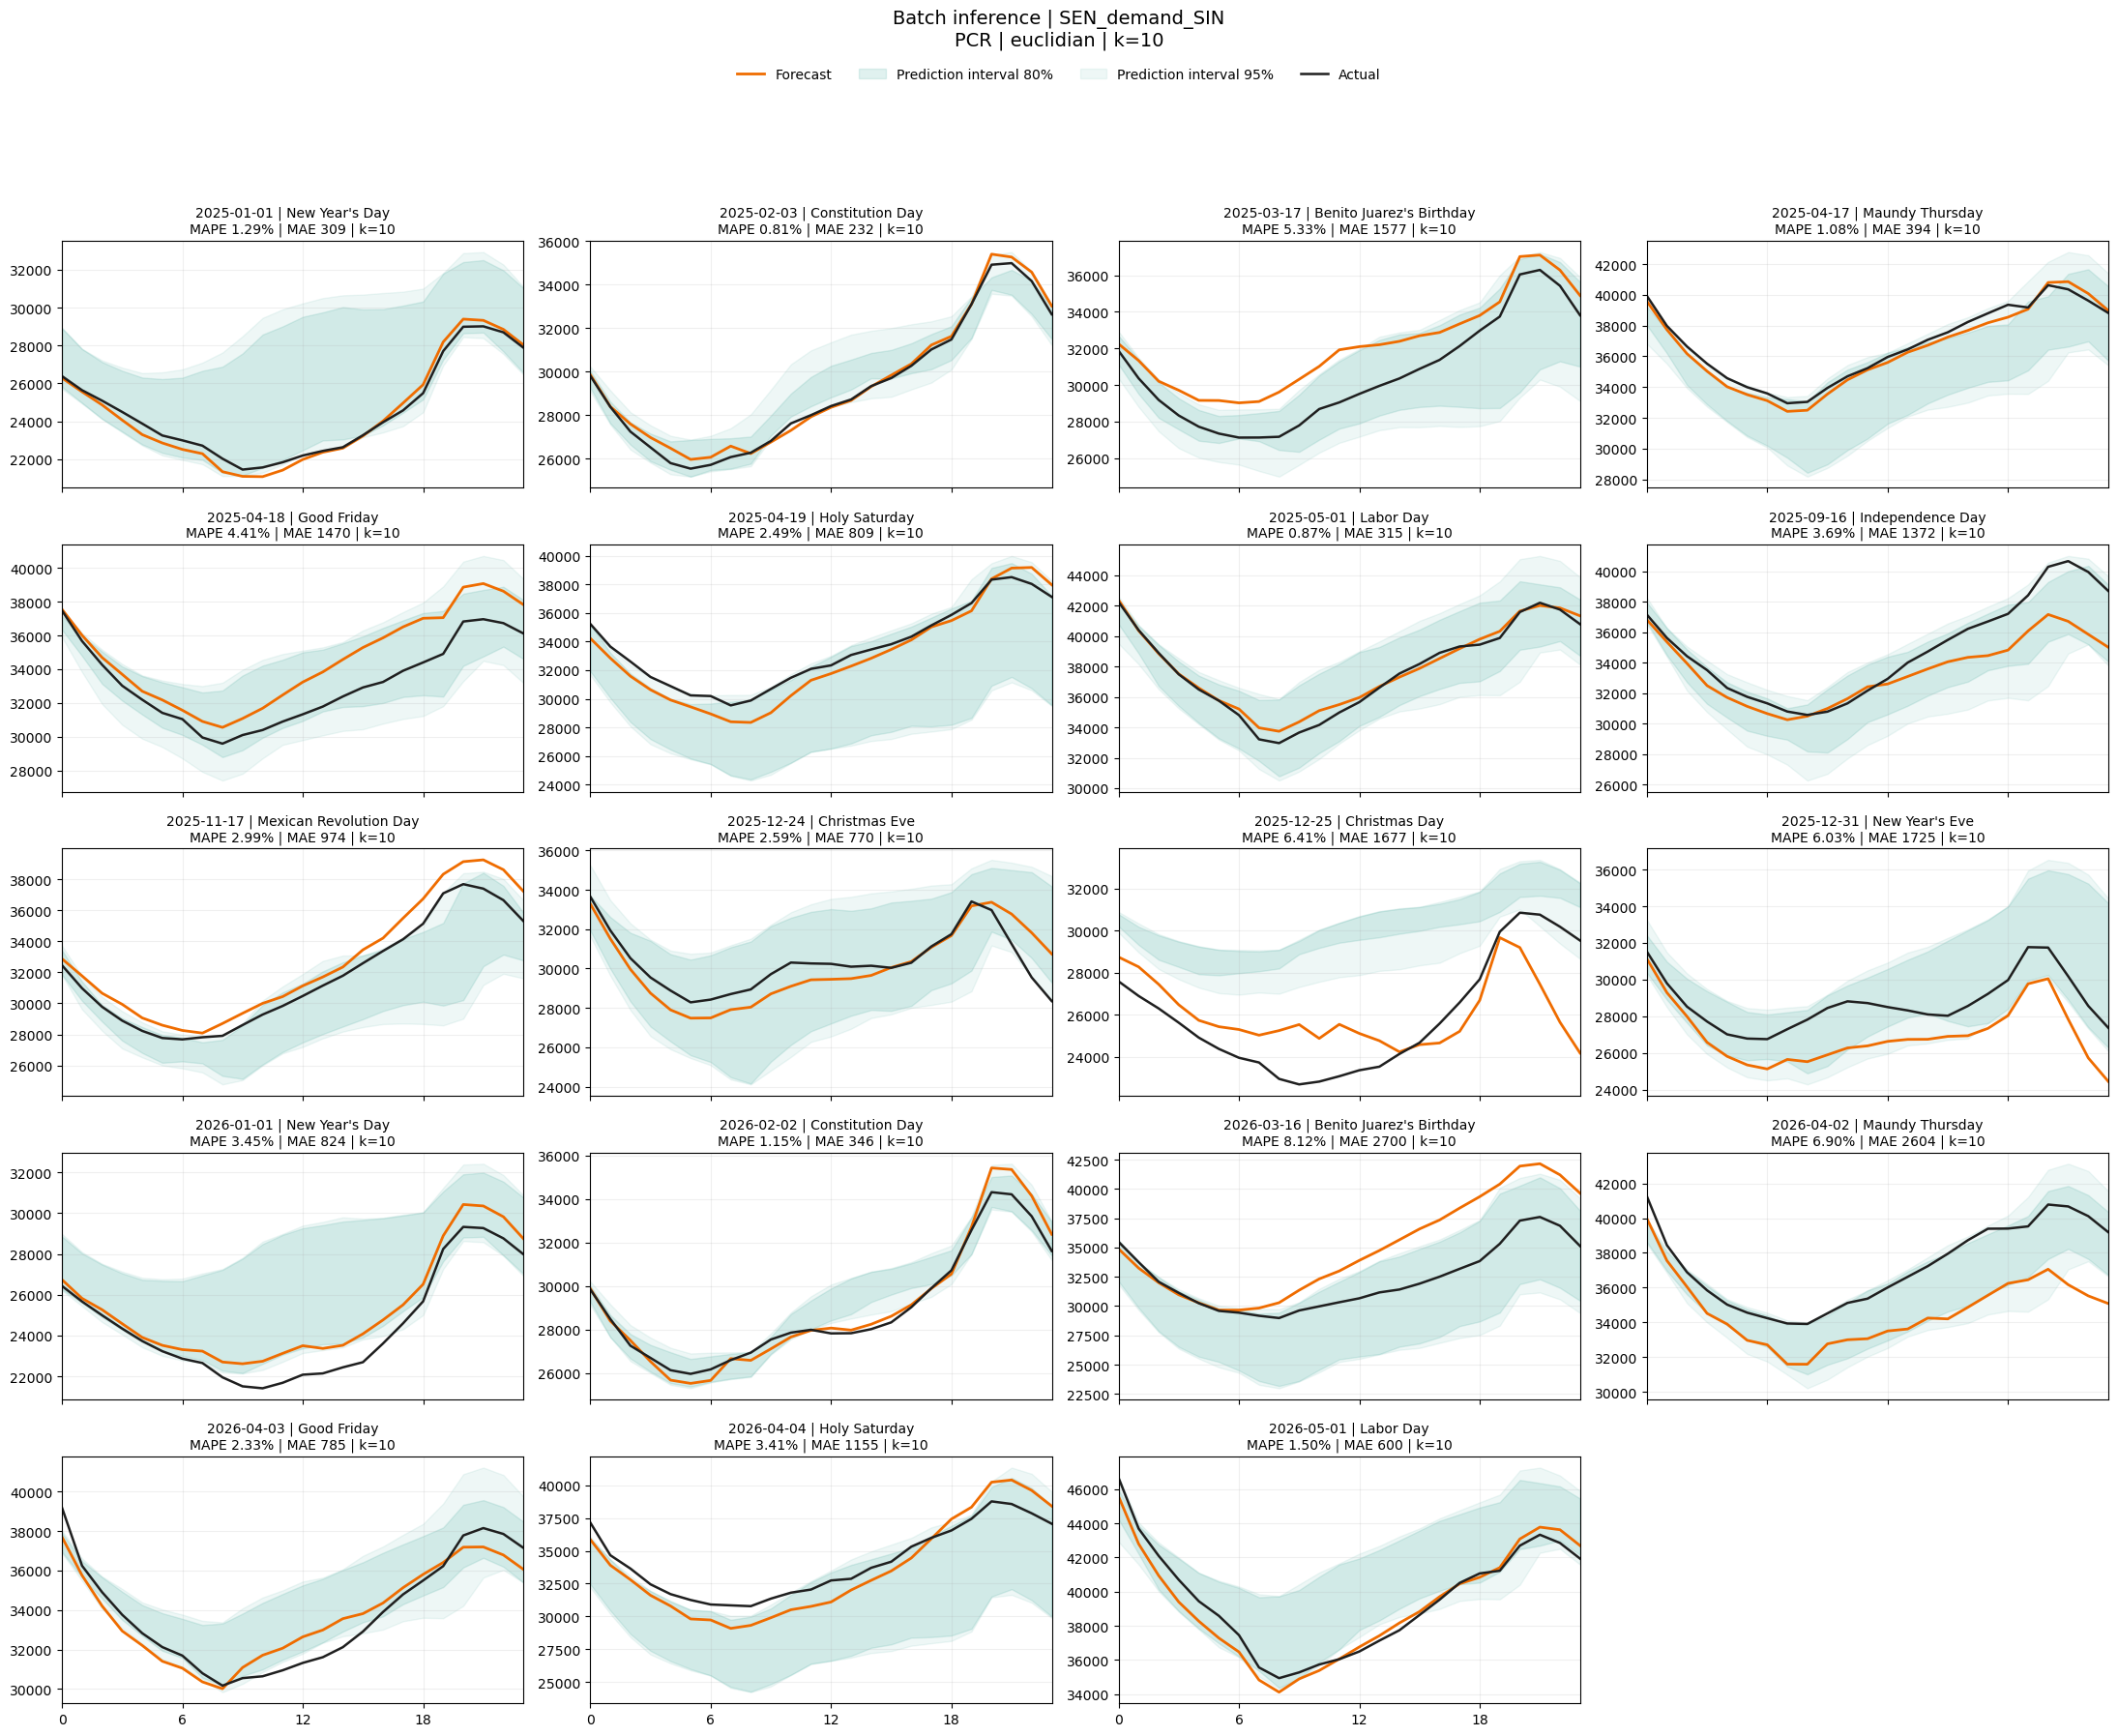

In [18]:
fig, axes = plot_batch_inference_grid(
    batch_result_2025,
    title=f'Batch inference | {UNIQUE_ID}\n{TYPEREG} | {TYPEDIST} | k={K}',
)
plt.show()

In [19]:
run = batch_result_2025.runs.get(TARGET_DATE)

if run is None:
    run = run_analog_holidays(
        unique_id=UNIQUE_ID,
        target_date=TARGET_DATE,
        source_path=SOURCE_PATH,
        season_length=SEASON_LENGTH,
        k=K,
        typedist=TYPEDIST,
        typereg=TYPEREG,
        n_components=N_COMPONENTS,
        levels=LEVELS,
        special_labels=SPECIAL_LABELS,
        min_special_points=MIN_SPECIAL_POINTS,
        min_event_gap=MIN_EVENT_GAP,
        max_events=MAX_EVENTS,
    )

summary_df = build_run_summary(run)
print(summary_df.to_string(index=False))

                     metric          value
                  unique_id SEN_demand_SIN
                target_date     2026-05-01
              target_exists           True
target_has_complete_profile           True
               target_label        holiday
        target_holiday_name           <NA>
                   typedist      euclidian
                    typereg            PCR
                k_neighbors             10
                 train_days           1939
         special_days_train             75
           selected_analogs             10
                       fail          False
                  t_sel_sec       0.001994
                  t_reg_sec       0.001994
               mape_24h_pct          1.504


In [20]:
diagnostic_run = run_analog_holidays(
    unique_id=UNIQUE_ID,
    target_date=TARGET_DATE,
    source_path=SOURCE_PATH,
    season_length=SEASON_LENGTH,
    k=K,
    typedist=TYPEDIST,
    typereg=TYPEREG,
    n_components=N_COMPONENTS,
    levels=LEVELS,
    special_labels=SPECIAL_LABELS,
    min_special_points=MIN_SPECIAL_POINTS,
    min_event_gap=MIN_EVENT_GAP,
    max_events=MAX_EVENTS,
    expected_target_label=None,
)

interval_rows = []
for lv in LEVELS:
    lo = diagnostic_run.interval_low.get(lv)
    hi = diagnostic_run.interval_high.get(lv)
    if lo is None or hi is None:
        continue
    width = hi - lo
    interval_rows.append({
        'level': lv,
        'average_interval_width': float(np.mean(width)),
        'max_interval_width': float(np.max(width)),
        'min_interval_width': float(np.min(width)),
    })

display(pd.DataFrame(interval_rows))

level_to_show = 95 if 95 in LEVELS else max(LEVELS)
hourly_interval_df = pd.DataFrame({
    'hour': np.arange(1, len(diagnostic_run.forecast_profile) + 1),
    'forecast_mean': diagnostic_run.forecast_profile,
    f'lower_limit_{level_to_show}': diagnostic_run.interval_low[level_to_show],
    f'upper_limit_{level_to_show}': diagnostic_run.interval_high[level_to_show],
})

hourly_interval_df.head(10)

,level,average_interval_width,max_interval_width,min_interval_width
0,80,3830.227591,5352.459043,1648.130061
1,95,4660.373189,6692.052461,2456.920828


,hour,forecast_mean,lower_limit_95,upper_limit_95
0,1,45575.502163,42923.548653,46750.344729
1,2,42798.952961,41592.618650,44049.539478
2,3,40937.898933,40025.127617,42880.337592
3,4,39396.783122,38819.534299,42001.063105
4,5,38270.303179,37786.094046,41107.100548
5,6,37281.534431,36741.272744,40641.061982
6,7,36468.916253,36159.704303,40302.964360
7,8,34824.401467,35031.854953,39852.487057
8,9,34112.830771,34312.897608,39735.702263
9,10,34889.733863,34873.108930,40422.279606


### X/X2 and Y/Y2 Sequences — Batch Grid

Una gráfica por fecha pronosticada, mostrando los pares históricos X/X2 en azul claro y la secuencia Y/Y2 forecast en rojo.


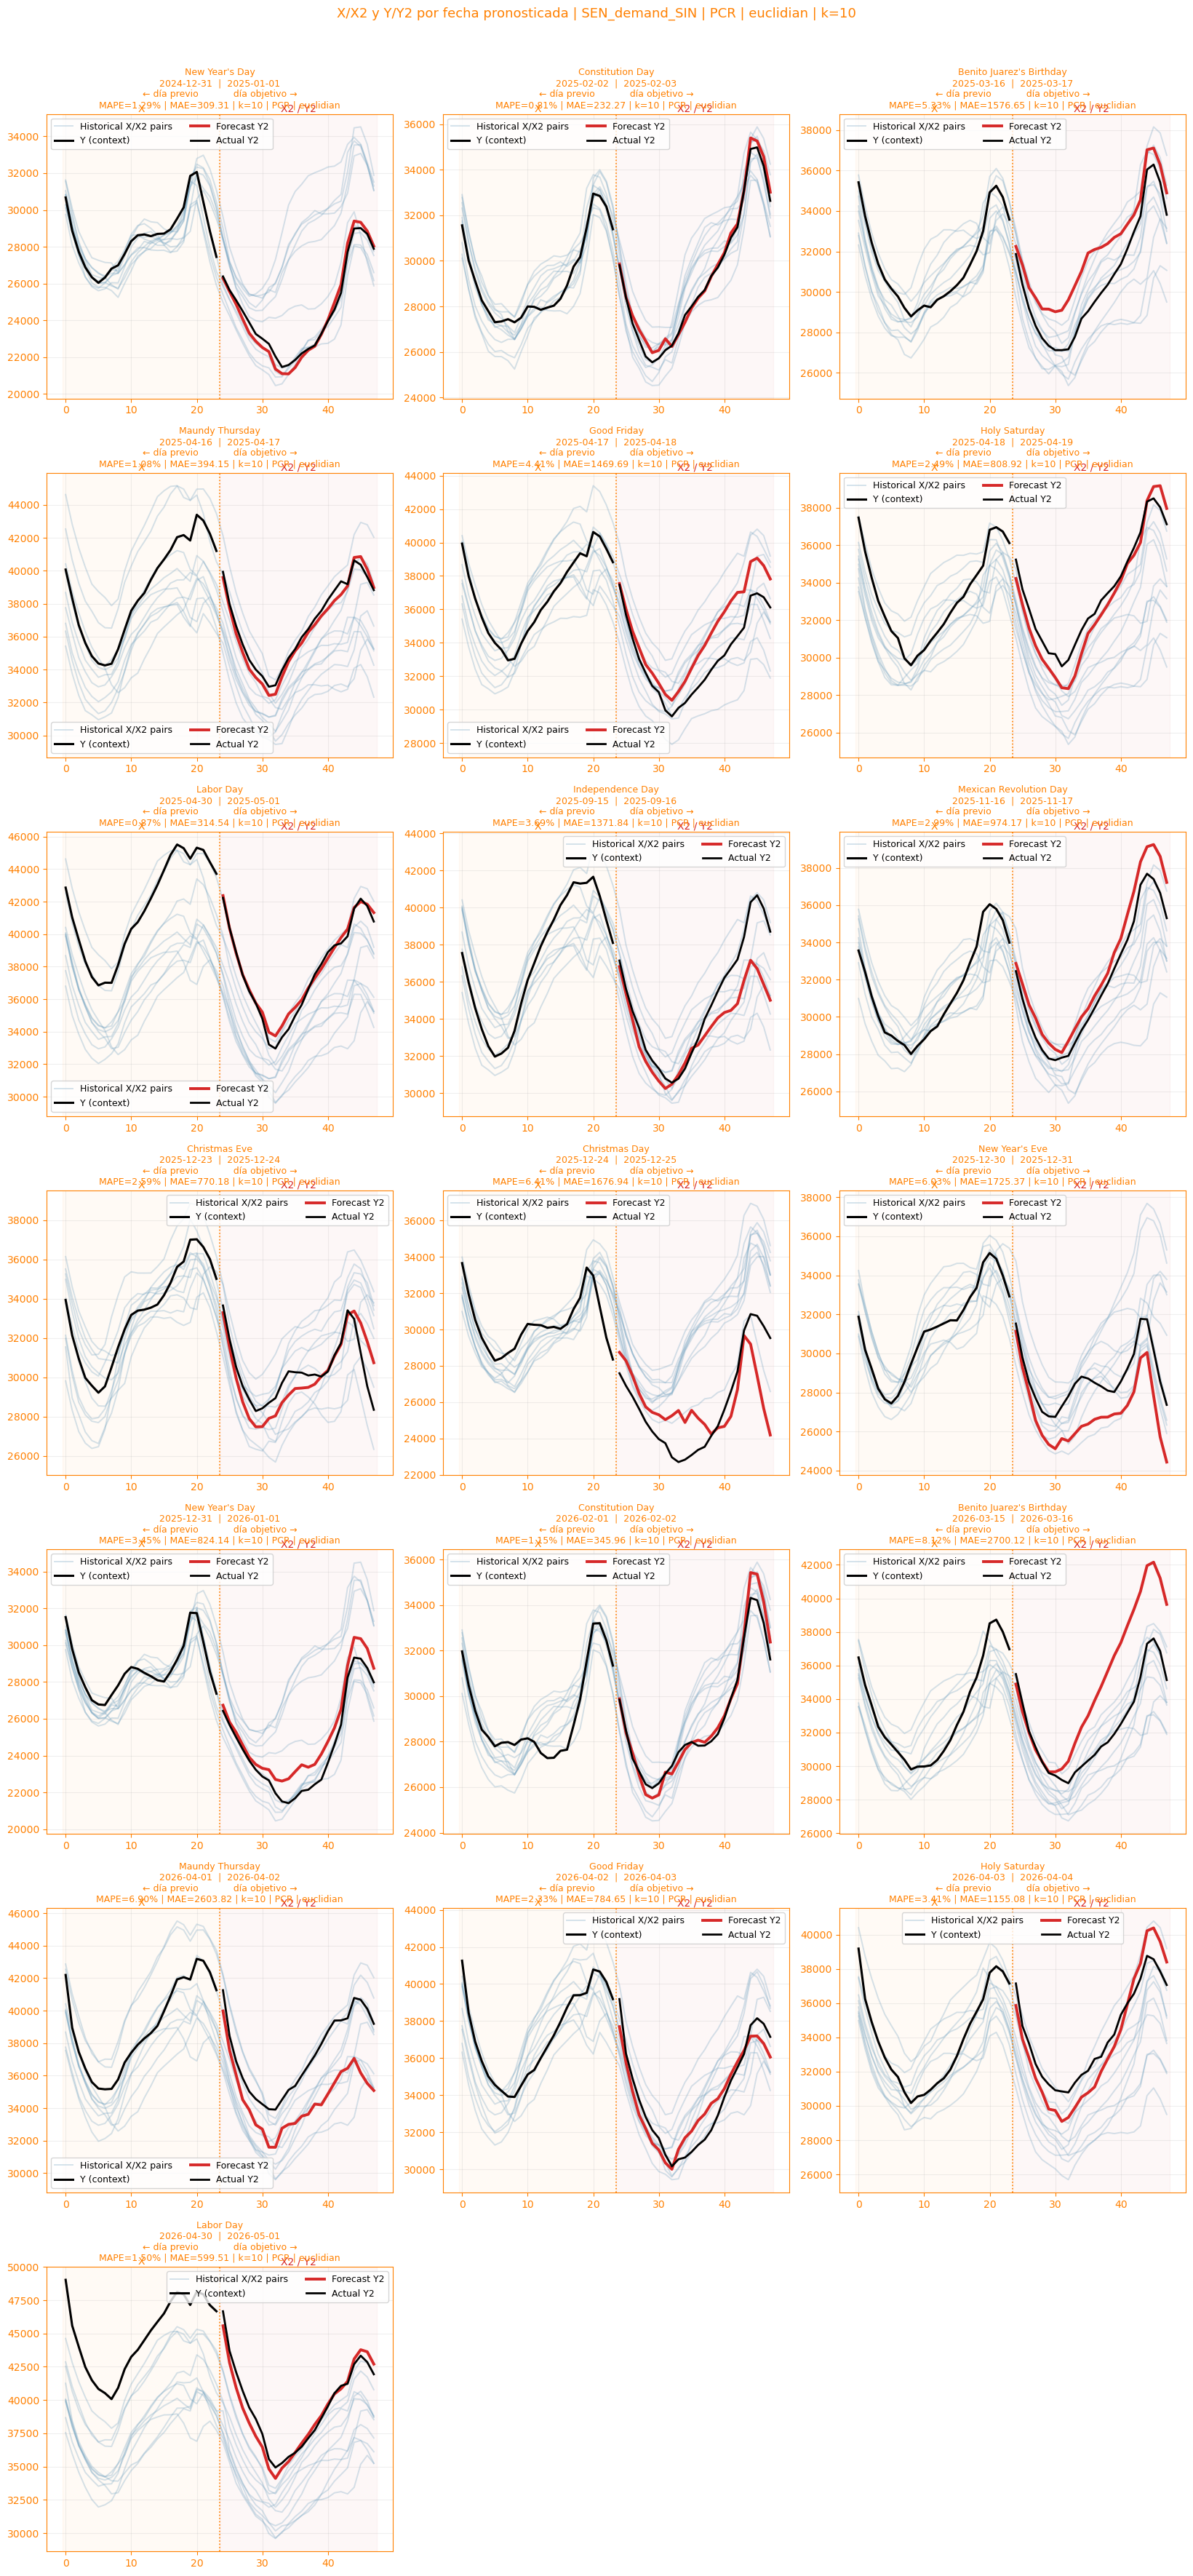

In [21]:
fig_seq, axes_seq = plot_batch_pair_sequences_grid(batch_result_2025)
plt.show()

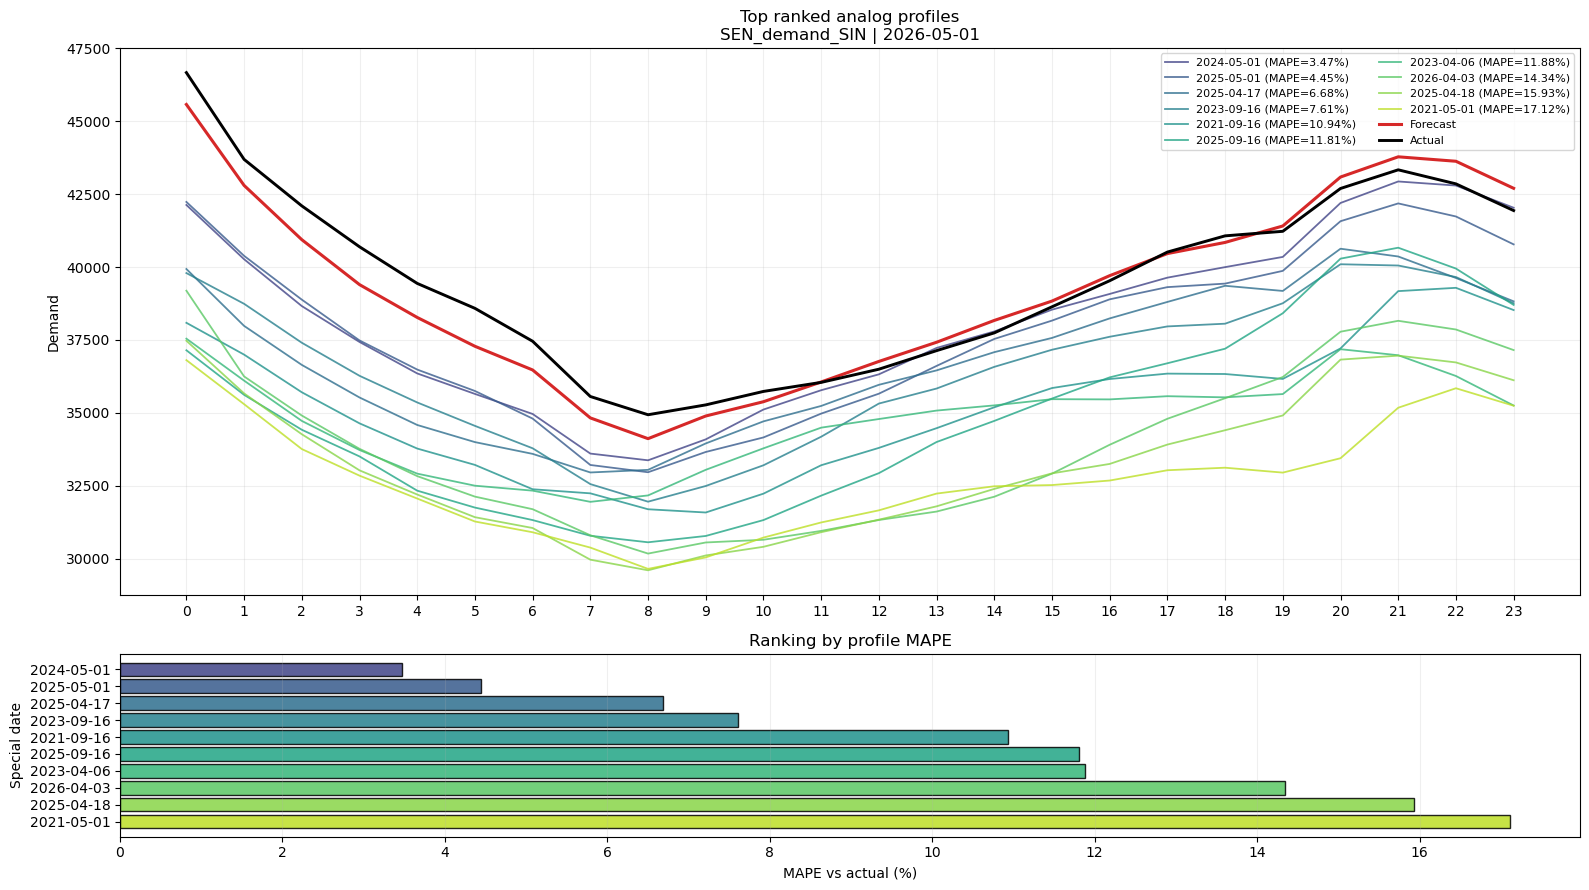

,analog_index,context_date,special_date,label,mape_vs_reference_pct,profile_max,reference_name
0,2,2024-04-30,2024-05-01,holiday,3.470065,42934.17318,actual
1,1,2025-04-30,2025-05-01,holiday,4.448655,42232.67565,actual
2,3,2025-04-16,2025-04-17,holiday,6.682201,40627.53867,actual
3,0,2023-09-15,2023-09-16,holiday,7.610149,40095.04809,actual
4,4,2021-09-15,2021-09-16,holiday,10.936852,39286.59522,actual
5,7,2025-09-15,2025-09-16,holiday,11.810172,40662.36839,actual
6,5,2023-04-05,2023-04-06,holiday,11.882760,37542.56199,actual
7,6,2026-04-02,2026-04-03,holiday,14.338556,39188.00000,actual
8,9,2025-04-17,2025-04-18,holiday,15.927410,37471.24967,actual
9,8,2021-04-30,2021-05-01,holiday,17.117264,36806.22100,actual


In [22]:
ranking_df = build_analog_ranking_table(run)
fig, axes = plot_ranked_analog_profiles(run, top_n=MAX_PLOTTED_ANALOGS)
plt.show()
ranking_df.head(MAX_PLOTTED_ANALOGS)